## a general descriotion of the cleaned data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
import pandas as pd
file="../cleaned/benin-cleaned.csv"

df = pd.read_csv(file)

In [5]:
print("The description of the numeric columns:")
print(df.describe())

The description of the numeric columns:
              GHI         DNI         DHI        ModA        ModB        Tamb  \
count  483.000000  483.000000  483.000000  483.000000  483.000000  483.000000   
mean   317.887371  253.784058  184.198551  308.255694  302.947826   26.232298   
std    149.260927  219.011543   73.666488  159.517279  153.209243    3.771837   
min     35.700000    0.000000   35.400000   37.100000   37.300000   16.300000   
25%    213.300000   26.450000  134.050000  188.350000  186.400000   23.800000   
50%    309.000000  232.400000  172.900000  292.600000  283.500000   26.300000   
75%    393.200000  407.300000  222.950000  394.850000  376.400000   28.650000   
max    869.000000  802.000000  558.000000  914.000000  917.000000   41.000000   

               RH          WS      WSgust     WSstdev          WD     WDstdev  \
count  483.000000  483.000000  483.000000  483.000000  483.000000  483.000000   
mean    60.290890    2.534369    3.375569    0.545342  168.986957   

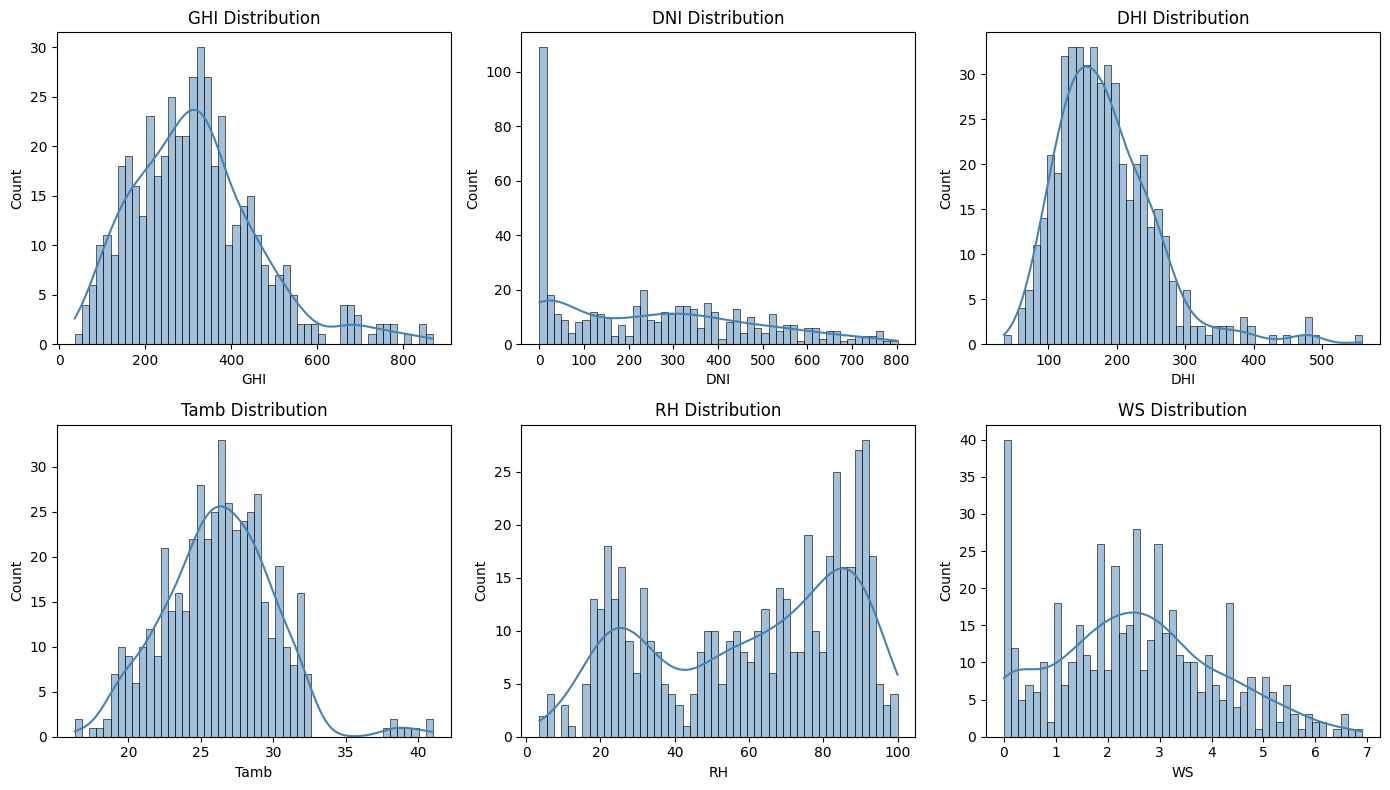

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# Choose key variables for visualization (you can modify this list)
cols_to_plot = ["GHI", "DNI", "DHI", "Tamb", "RH", "WS"]

# Plot settings
plt.figure(figsize=(14, 8))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color="steelblue")
    plt.title(f"{col} Distribution", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


## checking the time of the day where rradiance variables are high 

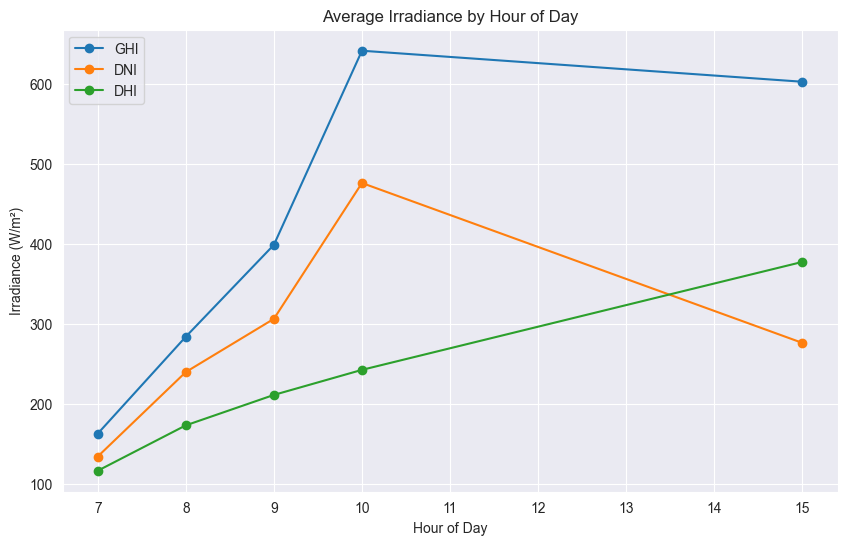

In [6]:
import pandas as pd
import matplotlib.pyplot as plt



# Convert timestamp to datetime and extract hour
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

# Compute average irradiance per hour
hourly_mean = df.groupby('Hour')[['GHI', 'DNI', 'DHI']].mean()

# Plot
hourly_mean.plot(kind='line', figsize=(10,6), marker='o')
plt.title("Average Irradiance by Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.xlabel("Hour of Day")
plt.grid(True)
plt.show()


## checking when the wind varibables are high

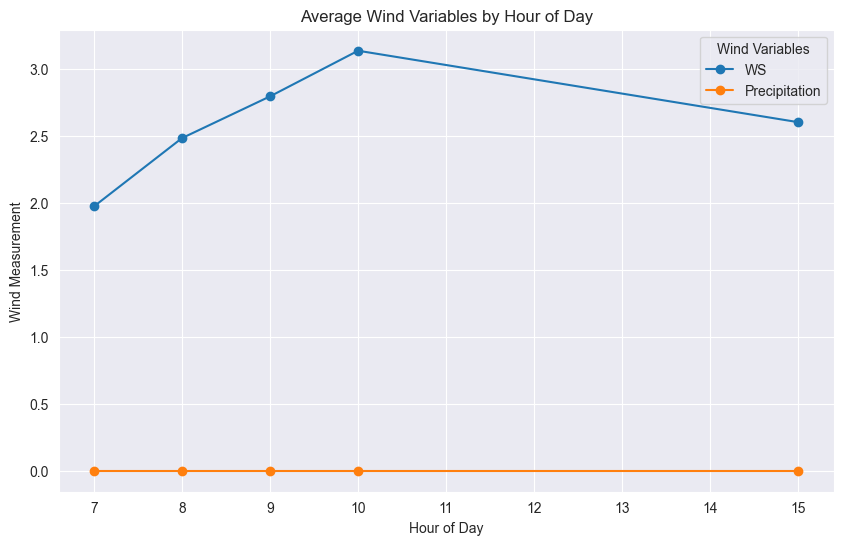

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Timestamp to datetime and extract hour
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

# Select wind-related columns
wind_cols = ['WS']

# Compute average per hour
hourly_wind_mean = df.groupby('Hour')[wind_cols].mean()

# Plot
hourly_wind_mean.plot(kind='line', figsize=(10,6), marker='o')
plt.title("Average Wind Variables by Hour of Day")
plt.ylabel("Wind Measurement")
plt.xlabel("Hour of Day")
plt.grid(True)
plt.legend(title="Wind Variables")
plt.show()

✅ Cleaned dataset shape: (451, 18)

☀️ Average Irradiance Values (Cleaned Dataset):
GHI: 297.12 W/m²
DNI: 246.89 W/m²
DHI: 174.46 W/m²

📁 Saved summary averages to: ../cleaned/benin-irradiance-summary.csv


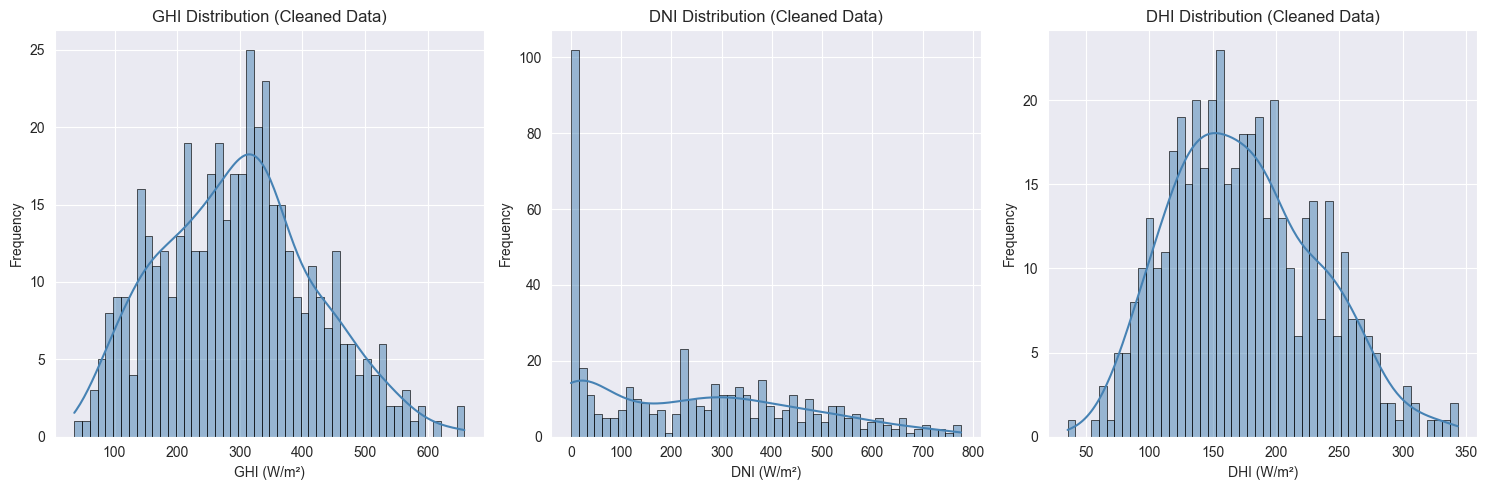

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Step 1: Load the cleaned dataset ===
input_path = "../cleaned/benin-cleaned.csv"  # change this for each country
df = pd.read_csv(input_path)

# === Step 2: Convert Timestamp to datetime (if not already) ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# === Step 3: Select irradiance columns ===
irradiance_cols = ['GHI', 'DNI', 'DHI']

# === Step 4: Double-check no negative values remain ===
df[irradiance_cols] = df[irradiance_cols].clip(lower=0)

# === Step 5: Remove zeros (keep only daylight observations) ===
daylight_df = df[(df['GHI'] > 0) & (df['DNI'] > 0) & (df['DHI'] > 0)].copy()

# === Step 6: Remove outliers using IQR ===
for col in irradiance_cols:
    Q1 = daylight_df[col].quantile(0.25)
    Q3 = daylight_df[col].quantile(0.75)
    IQR = Q3 - Q1
    daylight_df = daylight_df[
        (daylight_df[col] >= Q1 - 1.5 * IQR) &
        (daylight_df[col] <= Q3 + 1.5 * IQR)
    ]

print(f"✅ Cleaned dataset shape: {daylight_df.shape}")

# === Step 7: Compute average irradiance values ===
mean_values = daylight_df[irradiance_cols].mean()
print("\n☀️ Average Irradiance Values (Cleaned Dataset):")
for col, val in mean_values.items():
    print(f"{col}: {val:.2f} W/m²")

# === Optional: Save the averages to a summary file ===
summary_path = "../cleaned/benin-irradiance-summary.csv"
pd.DataFrame(mean_values, columns=['Average (W/m²)']).to_csv(summary_path)
print(f"\n📁 Saved summary averages to: {summary_path}")

# === Step 8: Plot histograms ===
sns.set_style('darkgrid')
plt.figure(figsize=(15, 5))

for i, col in enumerate(irradiance_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(daylight_df[col], bins=50, kde=True, color='steelblue', edgecolor='black')
    plt.title(f'{col} Distribution (Cleaned Data)')
    plt.xlabel(f'{col} (W/m²)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


## Computing Daily Total GHI


📊 Daily Irradiance Summary:
               GHI
count   241.000000
mean    637.093776
std     326.276726
min     103.900000
25%     414.000000
50%     611.300000
75%     788.000000
max    2401.700000


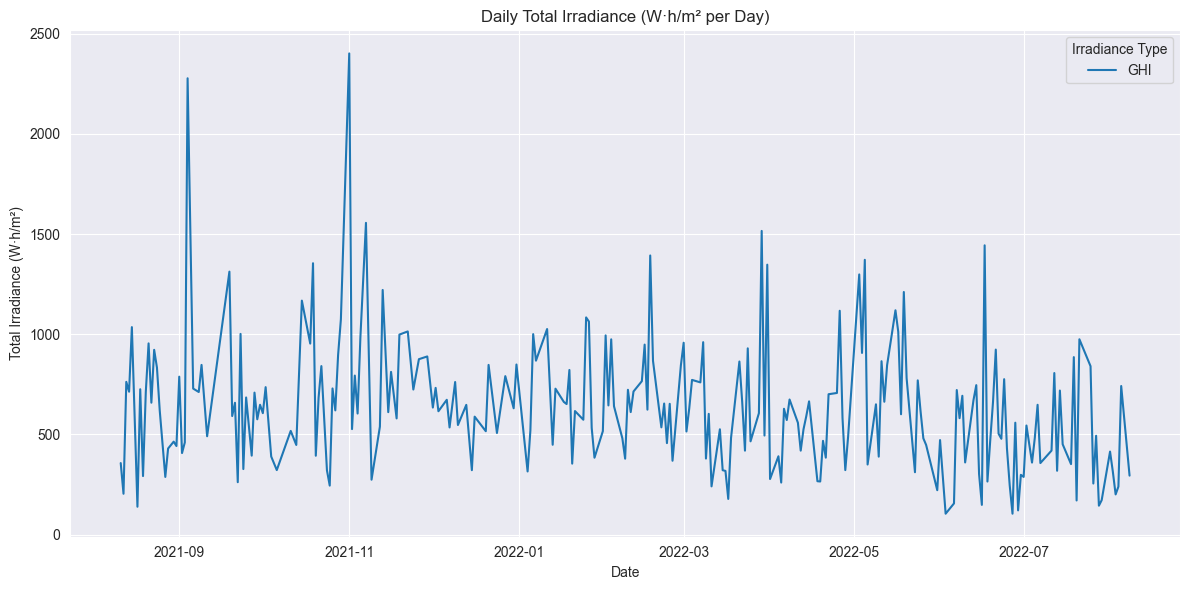

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Load the cleaned dataset ===
df = pd.read_csv("../cleaned/benin-cleaned.csv")  # change for each country

# === Step 2: Convert Timestamp to datetime ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# === Step 3: Extract the date part only ===
df['Date'] = df['Timestamp'].dt.date

# === Step 4: Group by date and compute total daily irradiance ===
# If your data is in intervals (e.g., minutes), sum() approximates daily energy per m².
daily_irradiance = df.groupby('Date')[['GHI']].sum()

# === Step 5: Display summary stats ===
print("\n📊 Daily Irradiance Summary:")
print(daily_irradiance.describe())

# === Step 6: Plot daily total irradiance over time ===
daily_irradiance.plot(figsize=(12,6))
plt.title("Daily Total Irradiance (W·h/m² per Day)")
plt.xlabel("Date")
plt.ylabel("Total Irradiance (W·h/m²)")
plt.grid(True)
plt.legend(title="Irradiance Type")
plt.tight_layout()
plt.show()


## wind speed

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your cleaned dataset (change path for each country)
df = pd.read_csv("../filtered/benin-filtered.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Replace negatives or NaNs with 0
df['WS'] = df['WS'].clip(lower=0)

# Compute daily averages of wind speed
daily_avg_ws = df.groupby(df['Timestamp'].dt.date)['WS'].mean()

# Compute summary statistics
min_avg = daily_avg_ws.min()
max_avg = daily_avg_ws.max()
mean_avg = daily_avg_ws.mean()

# Print summary
print("Daily Average Wind Speed Summary (m/s)")
print(f"Minimum Daily Average: {min_avg:.2f} m/s")
print(f"Maximum Daily Average: {max_avg:.2f} m/s")
print(f"Overall Mean of Daily Averages: {mean_avg:.2f} m/s")


Daily Average Wind Speed Summary (m/s)
Minimum Daily Average: 0.77 m/s
Maximum Daily Average: 5.39 m/s
Overall Mean of Daily Averages: 2.93 m/s


## wind speed gust 

💨 Daily Average WSgust Summary (m/s)
Minimum Daily Average: 1.24 m/s
Maximum Daily Average: 6.99 m/s
Overall Mean of Daily Averages: 3.89 m/s


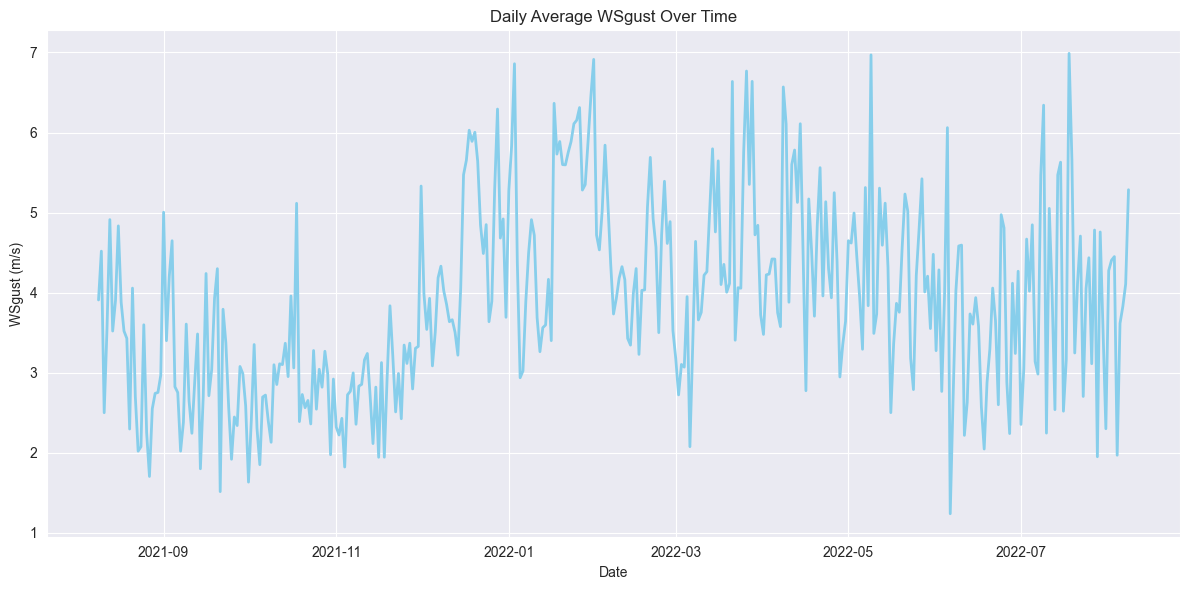

In [8]:
import pandas as pd

# === Step 1: Load the cleaned dataset ===
df = pd.read_csv("../filtered/benin-filtered.csv")  # change for each country

# === Step 2: Convert Timestamp to datetime and extract date ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

# === Step 3: Compute the daily average WSgust ===
daily_avg_wsgust = df.groupby('Date')['WSgust'].mean()

# === Step 4: Calculate key statistics ===
min_avg = daily_avg_wsgust.min()
max_avg = daily_avg_wsgust.max()
mean_avg = daily_avg_wsgust.mean()

# === Step 5: Display results ===
print("💨 Daily Average WSgust Summary (m/s)")
print(f"Minimum Daily Average: {min_avg:.2f} m/s")
print(f"Maximum Daily Average: {max_avg:.2f} m/s")
print(f"Overall Mean of Daily Averages: {mean_avg:.2f} m/s")

# === Step 6 (Optional): Plot variation over time ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
daily_avg_wsgust.plot(color='skyblue', linewidth=2)
plt.title("Daily Average WSgust Over Time")
plt.xlabel("Date")
plt.ylabel("WSgust (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()


## precipitation

In [3]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("../filtered/benin-filtered.csv")

# Ensure Timestamp is datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Replace missing or negative precipitation values with 0 (if needed)
df['Precipitation'] = df['Precipitation'].clip(lower=0)

# Group by day and calculate daily average precipitation
daily_avg_precip = df.groupby(df['Timestamp'].dt.date)['Precipitation'].mean()

# Compute summary statistics
min_avg = daily_avg_precip.min()
max_avg = daily_avg_precip.max()
mean_avg = daily_avg_precip.mean()

# Print summary
print("Daily Average Precipitation Summary (mm)")
print(f"Minimum Daily Average: {min_avg:.2f} mm")
print(f"Maximum Daily Average: {max_avg:.2f} mm")
print(f"Overall Mean of Daily Averages: {mean_avg:.2f} mm")


Daily Average Precipitation Summary (mm)
Minimum Daily Average: 0.00 mm
Maximum Daily Average: 0.00 mm
Overall Mean of Daily Averages: 0.00 mm


## imputation
## filtered + no out liers 

✅ Cleaned dataset shape: (185696, 23)

☀️ Average Irradiance Values (Cleaned Dataset):
GHI: 612.41 W/m²
DNI: 468.79 W/m²
DHI: 262.36 W/m²

📁 Saved summary averages to: ../filtered/benin-irradiance-summary.csv


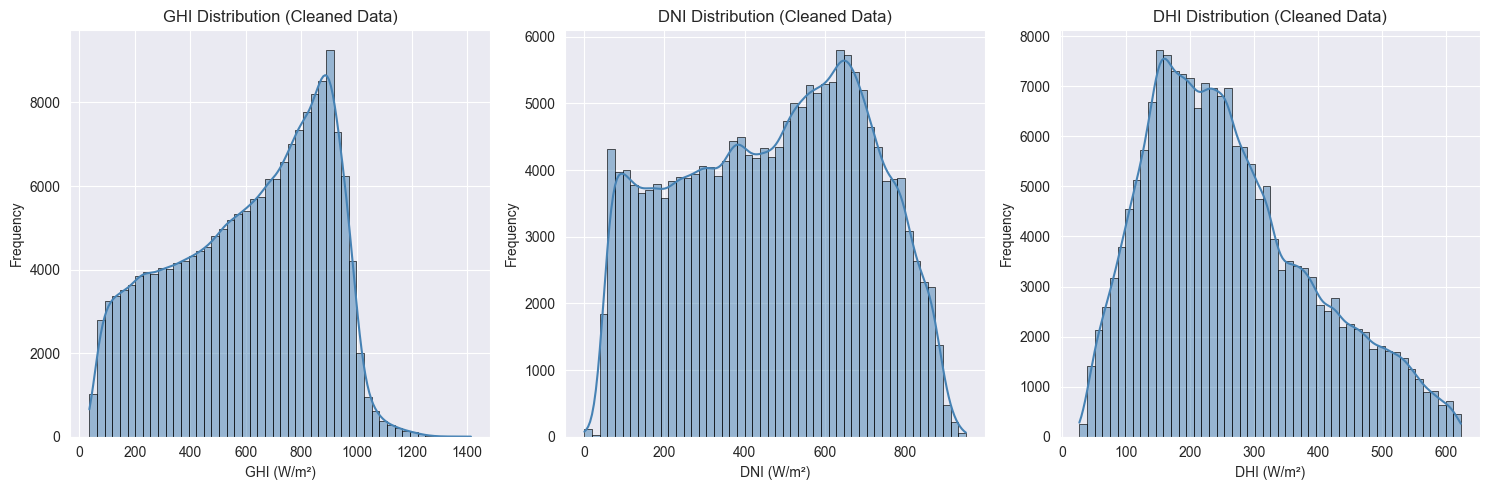

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Step 1: Load the cleaned dataset ===
input_path = "../filtered/benin-filtered.csv"  # change this for each country
df = pd.read_csv(input_path)

# === Step 2: Convert Timestamp to datetime (if not already) ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# === Step 3: Select irradiance columns ===
irradiance_cols = ['GHI', 'DNI', 'DHI']

# === Step 4: Double-check no negative values remain ===
df[irradiance_cols] = df[irradiance_cols].clip(lower=0)

# === Step 5: Remove zeros (keep only daylight observations) ===
daylight_df = df[(df['GHI'] > 0) & (df['DNI'] > 0) & (df['DHI'] > 0)].copy()

# === Step 6: Remove outliers using IQR ===
for col in irradiance_cols:
    Q1 = daylight_df[col].quantile(0.25)
    Q3 = daylight_df[col].quantile(0.75)
    IQR = Q3 - Q1
    daylight_df = daylight_df[
        (daylight_df[col] >= Q1 - 1.5 * IQR) &
        (daylight_df[col] <= Q3 + 1.5 * IQR)
    ]

print(f"✅ Cleaned dataset shape: {daylight_df.shape}")

# === Step 7: Compute average irradiance values ===
mean_values = daylight_df[irradiance_cols].mean()
print("\n☀️ Average Irradiance Values (Cleaned Dataset):")
for col, val in mean_values.items():
    print(f"{col}: {val:.2f} W/m²")

# === Optional: Save the averages to a summary file ===
summary_path = "../filtered/benin-irradiance-summary.csv"
pd.DataFrame(mean_values, columns=['Average (W/m²)']).to_csv(summary_path)
print(f"\n📁 Saved summary averages to: {summary_path}")

# === Step 8: Plot histograms ===
sns.set_style('darkgrid')
plt.figure(figsize=(15, 5))

for i, col in enumerate(irradiance_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(daylight_df[col], bins=50, kde=True, color='steelblue', edgecolor='black')
    plt.title(f'{col} Distribution (Cleaned Data)')
    plt.xlabel(f'{col} (W/m²)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


## checking time of he day where irradiance variables are high

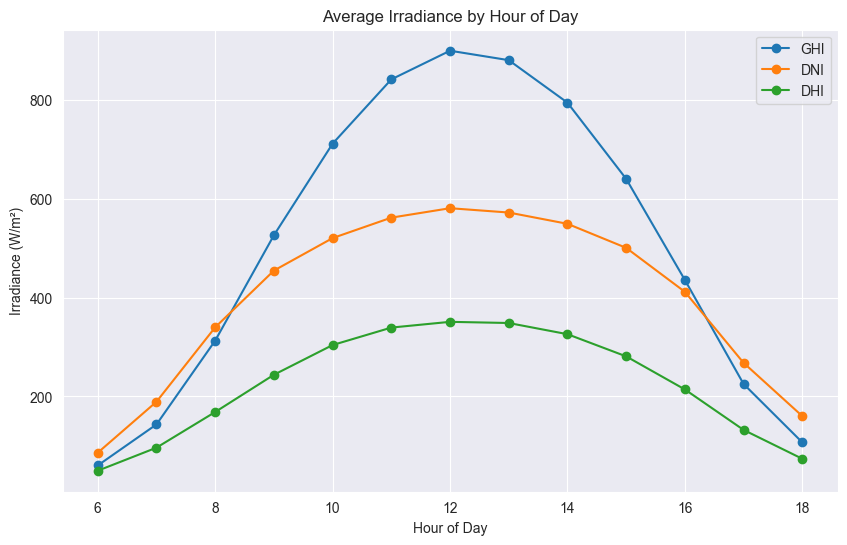

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../filtered/benin-filtered.csv") 

# Convert timestamp to datetime and extract hour
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

# Compute average irradiance per hour
hourly_mean = df.groupby('Hour')[['GHI', 'DNI', 'DHI']].mean()

# Plot
hourly_mean.plot(kind='line', figsize=(10,6), marker='o')
plt.title("Average Irradiance by Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.xlabel("Hour of Day")
plt.grid(True)
plt.show()

## correlation between irradiance variables, precipitation and wind speed 

🔍 Correlation Matrix (Positive Irradiance Only):

                    GHI       DNI       DHI        WS  Precipitation      Tamb
GHI            1.000000  0.651247  0.551942  0.295878      -0.002804  0.320913
DNI            0.651247  1.000000 -0.221508  0.194449      -0.005714  0.126901
DHI            0.551942 -0.221508  1.000000  0.207892       0.002826  0.238974
WS             0.295878  0.194449  0.207892  1.000000      -0.000064  0.005313
Precipitation -0.002804 -0.005714  0.002826 -0.000064       1.000000 -0.006665
Tamb           0.320913  0.126901  0.238974  0.005313      -0.006665  1.000000


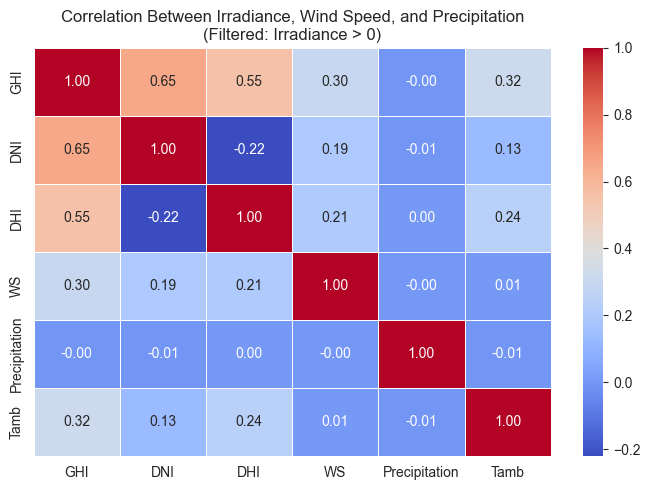

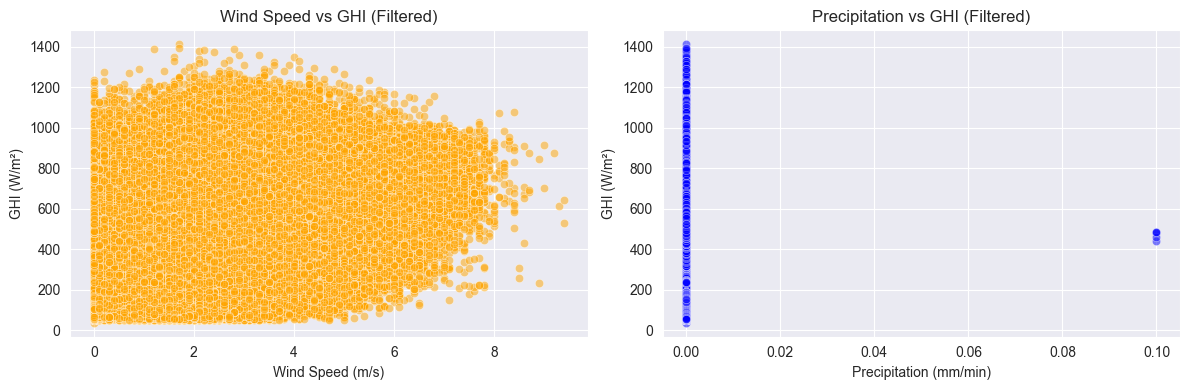

In [12]:
# --- Correlation Between Irradiance, Wind Speed, and Precipitation (Filtered) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Load and prepare data
df = pd.read_csv("../filtered/benin-filtered.csv")

# 2️⃣ Keep relevant columns
cols = ['GHI', 'DNI', 'DHI', 'WS', 'Precipitation', 'Tamb']
df = df[cols]

# 3️⃣ Remove rows where any irradiance value (GHI, DNI, DHI) <= 0
df = df[(df['GHI'] > 0) & (df['DNI'] > 0) & (df['DHI'] > 0)]

# 4️⃣ Compute correlation matrix
corr = df.corr()

# 5️⃣ Display correlation values
print("🔍 Correlation Matrix (Positive Irradiance Only):\n")
print(corr)

# 6️⃣ Plot correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Irradiance, Wind Speed, and Precipitation\n(Filtered: Irradiance > 0)')
plt.tight_layout()
plt.show()

# 7️⃣ Scatter plots to visualize relationships
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='WS', y='GHI', alpha=0.5, color='orange')
plt.title('Wind Speed vs GHI (Filtered)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('GHI (W/m²)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Precipitation', y='GHI', alpha=0.5, color='blue')
plt.title('Precipitation vs GHI (Filtered)')
plt.xlabel('Precipitation (mm/min)')
plt.ylabel('GHI (W/m²)')

plt.tight_layout()
plt.show()



## overall comparson of the country datas

In [ ]:
import pandas as pd

# Define file paths
countries = {
    'Benin': "../filtered/benin-filtered.csv",
    'Togo': "../filtered/togo-filtered.csv",
    'SierraLeone': "../filtered/sierraleone-filtered.csv"
}

# Initialize a results list
summary = []

# Loop through each dataset
for country, path in countries.items():
    # Load dataset
    df = pd.read_csv(path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Date'] = df['Timestamp'].dt.date

    # ---- Irradiance averages ----
    avg_GHI = df['GHI'].mean()
    avg_DNI = df['DNI'].mean()
    avg_DHI = df['DHI'].mean()

    # ---- Daily stats for environmental factors ----
    daily_stats = df.groupby('Date').agg({
        'WS': ['min', 'max', 'mean'],
        'WSgust': ['min', 'max', 'mean'],
        'Precipitation': ['min', 'max', 'mean'],
        'Tamb': ['min', 'max', 'mean']
    })

    # Flatten multi-level columns
    daily_stats.columns = ['_'.join(col) for col in daily_stats.columns]

    # Compute overall daily averages (mean of daily means)
    daily_avg = daily_stats.mean()

    # Store summarized data
    summary.append({
        'Country': country,
        'Avg_GHI': avg_GHI,
        'Avg_DNI': avg_DNI,
        'Avg_DHI': avg_DHI,
        'WS_Min': daily_avg['WS_min'],
        'WS_Max': daily_avg['WS_max'],
        'WS_Avg': daily_avg['WS_mean'],
        'WSgust_Min': daily_avg['WSgust_min'],
        'WSgust_Max': daily_avg['WSgust_max'],
        'WSgust_Avg': daily_avg['WSgust_mean'],
        'Precip_Min': daily_avg['Precipitation_min'],
        'Precip_Max': daily_avg['Precipitation_max'],
        'Precip_Avg': daily_avg['Precipitation_mean'],
        'Tamb_Min': daily_avg['Tamb_min'],
        'Tamb_Max': daily_avg['Tamb_max'],
        'Tamb_Avg': daily_avg['Tamb_mean']
    })

# Convert summary to DataFrame
summary_df = pd.DataFrame(summary)

# Display results
print("\n=== Country Comparison Summary ===\n")
print(summary_df.round(2))

# ---- Investment Recommendation ----
# Define simple scoring logic:
# High irradiance = good (+)
# Moderate wind = okay
# Low precipitation = good
# Moderate temperature = ideal

summary_df['Score'] = (
    (summary_df['Avg_GHI'] + summary_df['Avg_DNI']) / 2
    - (summary_df['Precip_Avg'] * 10)
    - (summary_df['WSgust_Avg'] * 2)
    - abs(summary_df['Tamb_Avg'] - 30)
)

best_country = summary_df.loc[summary_df['Score'].idxmax(), 'Country']

print("\n=== Investment Recommendation ===")
print(f"The most promising country for solar panel installation is **{best_country}** based on irradiance, temperature, and weather conditions.")

# Optional: Save comparison table
summary_df.to_csv("../final/final.csv", index=False)
print("\nDetailed comparison saved to '../final/final.csv'")



=== Country Comparison Summary ===

       Country  Avg_GHI  Avg_DNI  Avg_DHI  WS_Min  WS_Max  WS_Avg  WSgust_Min  \
0        Benin   614.30   466.19   265.75    0.30    5.82    2.93        0.55   
1         Togo   612.92   452.28   268.51    0.50    5.91    3.11        0.89   
2  SierraLeone   592.09   414.61   277.93    0.03    4.39    1.75        0.06   

   WSgust_Max  WSgust_Avg  Precip_Min  Precip_Max  Precip_Avg  Tamb_Min  \
0        7.43        3.89         0.0        0.00         0.0     23.21   
1        7.76        4.23         0.0        0.01         0.0     23.84   
2        5.85        2.55         0.0        0.01         0.0     22.87   

   Tamb_Max  Tamb_Avg  
0     35.99     31.86  
1     34.05     30.78  
2     33.17     29.96  

=== Investment Recommendation ===
The most promising country for solar panel installation is **Benin** based on irradiance, temperature, and weather conditions.

Detailed comparison saved to '../comparison/country_comparison.csv'


## over all when outliers are removed

In [17]:
import pandas as pd

# === Step 1: Define file paths ===
countries = {
    'Benin': "../filtered/benin-filtered.csv",
    'Togo': "../filtered/togo-filtered.csv",
    'SierraLeone': "../filtered/sierraleone-filtered.csv"
}

summary = []

# === Step 2: IQR Outlier Removal ===
def remove_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0 or pd.isna(IQR):  # skip if no variation
            continue
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

# === Step 3: Process Each Country ===
for country, path in countries.items():
    try:
        df = pd.read_csv(path)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Date'] = df['Timestamp'].dt.date

        df = remove_outliers_iqr(df)
        if df.empty:
            print(f"⚠️ {country}: No data left after cleaning, skipping...")
            continue

        # Compute irradiance metrics
        avg_GHI = df['GHI'].mean()
        avg_DNI = df['DNI'].mean()
        avg_DHI = df['DHI'].mean()

        # Daily averages for weather variables
        daily_stats = df.groupby('Date').agg({
            'WS': ['min', 'max', 'mean'],
            'WSgust': ['min', 'max', 'mean'],
            'Precipitation': ['min', 'max', 'mean'],
            'Tamb': ['min', 'max', 'mean']
        })
        daily_stats.columns = ['_'.join(col) for col in daily_stats.columns]
        daily_avg = daily_stats.mean()

        summary.append({
            'Country': country,
            'Avg_GHI': avg_GHI,
            'Avg_DNI': avg_DNI,
            'Avg_DHI': avg_DHI,
            'WS_Min': daily_avg.get('WS_min', 0),
            'WS_Max': daily_avg.get('WS_max', 0),
            'WS_Avg': daily_avg.get('WS_mean', 0),
            'WSgust_Min': daily_avg.get('WSgust_min', 0),
            'WSgust_Max': daily_avg.get('WSgust_max', 0),
            'WSgust_Avg': daily_avg.get('WSgust_mean', 0),
            'Precip_Min': daily_avg.get('Precipitation_min', 0),
            'Precip_Max': daily_avg.get('Precipitation_max', 0),
            'Precip_Avg': daily_avg.get('Precipitation_mean', 0),
            'Tamb_Min': daily_avg.get('Tamb_min', 0),
            'Tamb_Max': daily_avg.get('Tamb_max', 0),
            'Tamb_Avg': daily_avg.get('Tamb_mean', 0)
        })
    except Exception as e:
        print(f"❌ Error processing {country}: {e}")

# === Step 4: Summarize Results ===
summary_df = pd.DataFrame(summary)

if summary_df.empty:
    print("\n⚠️ No valid data found for comparison after cleaning.")
else:
    print("\n=== Country Comparison Summary ===\n")
    print(summary_df.round(2))

    # === Step 5: Scoring Safely ===
    summary_df['Score'] = (
        (summary_df['Avg_GHI'].fillna(0) + summary_df['Avg_DNI'].fillna(0)) / 2
        - (summary_df['Precip_Avg'].fillna(0) * 10)
        - (summary_df['WSgust_Avg'].fillna(0) * 2)
        - abs(summary_df['Tamb_Avg'].fillna(0) - 30)
    )

    if summary_df['Score'].isna().all():
        print("\n⚠️ Could not compute scores due to missing data.")
    else:
        best_country = summary_df.loc[summary_df['Score'].idxmax(), 'Country']
        print(f"\n✅ Recommended Investment Country: **{best_country}**")

    # === Step 6: Save Results ===
    summary_df.to_csv("../final/final2.csv", index=False)
    print("\n📁 Saved results to '../final/final2.csv'")



=== Country Comparison Summary ===

       Country  Avg_GHI  Avg_DNI  Avg_DHI  WS_Min  WS_Max  WS_Avg  WSgust_Min  \
0        Benin   611.31   468.40   262.81    0.45    5.59    2.95        1.11   
1         Togo   612.14   451.41   268.50    0.60    5.62    3.14        1.35   
2  SierraLeone   603.51   425.22   279.91    0.07    4.13    1.90        0.68   

   WSgust_Max  WSgust_Avg  Precip_Min  Precip_Max  Precip_Avg  Tamb_Min  \
0        6.86        3.86         0.0        0.00         0.0     24.04   
1        7.25        4.24         0.0        0.00         0.0     24.20   
2        5.22        2.73         0.0        0.01         0.0     24.10   

   Tamb_Max  Tamb_Avg  
0     35.97     32.13  
1     34.04     30.88  
2     33.20     30.43  

✅ Recommended Investment Country: **Benin**

📁 Saved results to '../final/final2.csv'


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

# Try to load the summary produced earlier; otherwise expect summary_df in memory
file_path = Path("../final/final2.csv")
if file_path.exists():
    summary_df = pd.read_csv(file_path)
else:
    try:
        summary_df  # use existing variable if present in notebook
    except NameError:
        raise RuntimeError("No summary dataframe found. Run the comparison code or place ../final/final2.csv.")

# Ensure countries column exists
if 'Country' not in summary_df.columns:
    raise RuntimeError("summary_df must contain a 'Country' column.")

# Metrics to evaluate and how to judge them
# 'mode' = 'max' means larger is better, 'min' means smaller is better,
# 'closest' means best is minimum absolute distance to target value
metrics = {
    'Avg_GHI': {'mode': 'max'},
    'Avg_DNI': {'mode': 'max'},
    'Avg_DHI': {'mode': 'max'},
    'WS_Avg': {'mode': 'min'},         # lower average wind speed preferred
    'WSgust_Avg': {'mode': 'min'},     # lower gusts preferred
    'Precip_Avg': {'mode': 'min'},     # less precipitation preferred
    'Tamb_Avg': {'mode': 'closest', 'target': 30}  # closer to 30°C is preferred
}

# Ensure numeric
for col in list(metrics.keys()) + ['Score']:
    if col in summary_df.columns:
        summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

# Build winners dict
winners = {}
metric_winners = {}

for metric, cfg in metrics.items():
    if metric not in summary_df.columns:
        metric_winners[metric] = None
        continue

    if cfg['mode'] == 'max':
        best_val = summary_df[metric].max()
        winners_list = summary_df.loc[summary_df[metric] == best_val, 'Country'].tolist()
    elif cfg['mode'] == 'min':
        best_val = summary_df[metric].min()
        winners_list = summary_df.loc[summary_df[metric] == best_val, 'Country'].tolist()
    elif cfg['mode'] == 'closest':
        target = cfg.get('target', 0)
        dist = (summary_df[metric] - target).abs()
        best_val = dist.min()
        winners_list = summary_df.loc[dist == best_val, 'Country'].tolist()
    else:
        winners_list = []

    metric_winners[metric] = {'winners': winners_list, 'value': best_val}

# Count wins (if tie, each tied country gets a win for that metric)
win_counts = {c: 0 for c in summary_df['Country']}
for metric, info in metric_winners.items():
    if info is None:
        continue
    for c in info['winners']:
        win_counts[c] += 1

# Build results table
wins_df = pd.DataFrame([
    {'Country': c, 'Wins': win_counts[c], **{m: (c in (metric_winners[m]['winners'] or [])) for m in metrics}}
    for c in win_counts
]).sort_values(by='Wins', ascending=False).reset_index(drop=True)

# Also show Score winner if Score exists
score_winner = None
if 'Score' in summary_df.columns and not summary_df['Score'].isna().all():
    best_score = summary_df['Score'].max()
    score_winner = summary_df.loc[summary_df['Score'] == best_score, 'Country'].tolist()

# Print nice output
print("\n=== Metric winners (per metric) ===")
for metric, info in metric_winners.items():
    if info is None:
        print(f"{metric}: (not available)")
    else:
        print(f"{metric}: winners = {info['winners']} (best metric value = {info['value']})")

print("\n=== Win counts summary ===")
print(wins_df.to_string(index=False))

if score_winner:
    print(f"\nOverall by Score: winner(s) = {score_winner} (Score = {best_score})")

# Final decision by number of wins
top_wins = wins_df.iloc[0]
print(f"\nFinal decision by metric-wins: {top_wins['Country']} wins the most metrics ({top_wins['Wins']} wins).")

# Save a CSV summary
out_path = Path("../final/metric_wins_summary.csv")
wins_df.to_csv(out_path, index=False)
print(f"\nSaved metric-wins summary to: {out_path}")



=== Metric winners (per metric) ===
Avg_GHI: winners = ['Togo'] (best metric value = 612.1441367641426)
Avg_DNI: winners = ['Benin'] (best metric value = 468.403652894479)
Avg_DHI: winners = ['SierraLeone'] (best metric value = 279.9106766124856)
WS_Avg: winners = ['SierraLeone'] (best metric value = 1.8996281606902377)
WSgust_Avg: winners = ['SierraLeone'] (best metric value = 2.727971422741469)
Precip_Avg: winners = ['Benin'] (best metric value = 6.681531493609289e-06)
Tamb_Avg: winners = ['SierraLeone'] (best metric value = 0.43061337138209765)

=== Win counts summary ===
    Country  Wins  Avg_GHI  Avg_DNI  Avg_DHI  WS_Avg  WSgust_Avg  Precip_Avg  Tamb_Avg
SierraLeone     4    False    False     True    True        True       False      True
      Benin     2    False     True    False   False       False        True     False
       Togo     1     True    False    False   False       False       False     False

Overall by Score: winner(s) = ['Benin'] (Score = 529.996227425889)




=== Metric winners (per metric) ===
Avg_GHI: winners = ['Togo'] (best metric value = 612.1441367641426)
Avg_DNI: winners = ['Benin'] (best metric value = 468.403652894479)
Avg_DHI: winners = ['SierraLeone'] (best metric value = 279.9106766124856)
WS_Avg: winners = ['SierraLeone'] (best metric value = 1.8996281606902377)
WSgust_Avg: winners = ['SierraLeone'] (best metric value = 2.727971422741469)
Precip_Avg: winners = ['Benin'] (best metric value = 6.681531493609289e-06)
Tamb_Avg: winners = ['SierraLeone'] (best metric value = 0.43061337138209765)

=== Win counts summary ===
    Country  Wins  Avg_GHI  Avg_DNI  Avg_DHI  WS_Avg  WSgust_Avg  Precip_Avg  Tamb_Avg
SierraLeone     4    False    False     True    True        True       False      True
      Benin     2    False     True    False   False       False        True     False
       Togo     1     True    False    False   False       False       False     False

Overall by Score: winner(s) = ['Benin'] (Score = 529.996227425889)



C:\Users\hp\AppData\Local\Temp\ipykernel_15508\2513649769.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wins_df, x="Country", y="Wins", palette="viridis")


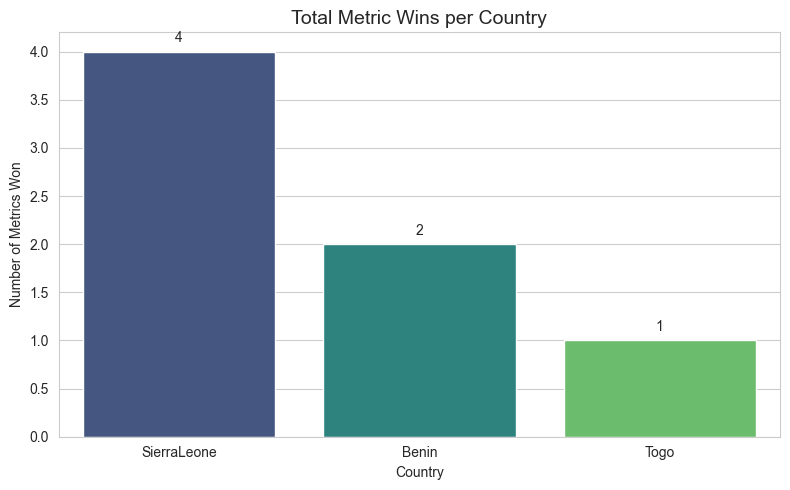

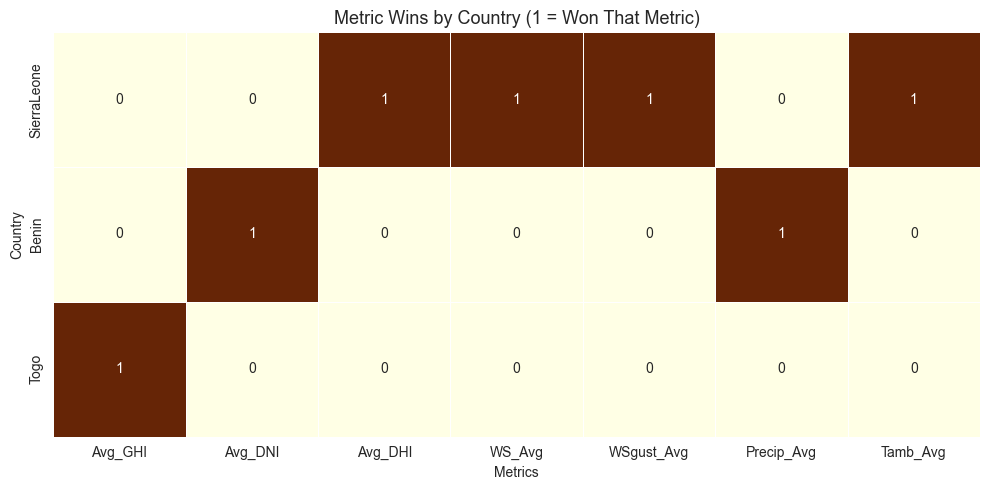

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# === Step 1: Load the summary data ===
file_path = Path("../final/final2.csv")
if file_path.exists():
    summary_df = pd.read_csv(file_path)
else:
    try:
        summary_df
    except NameError:
        raise RuntimeError("No summary dataframe found. Run the comparison code or place ../final/final2.csv.")

# Ensure Country column exists
if 'Country' not in summary_df.columns:
    raise RuntimeError("summary_df must contain a 'Country' column.")

# === Step 2: Define metrics ===
metrics = {
    'Avg_GHI': {'mode': 'max'},
    'Avg_DNI': {'mode': 'max'},
    'Avg_DHI': {'mode': 'max'},
    'WS_Avg': {'mode': 'min'},
    'WSgust_Avg': {'mode': 'min'},
    'Precip_Avg': {'mode': 'min'},
    'Tamb_Avg': {'mode': 'closest', 'target': 30}
}

# Ensure numeric columns
for col in list(metrics.keys()) + ['Score']:
    if col in summary_df.columns:
        summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

# === Step 3: Determine metric winners ===
metric_winners = {}
for metric, cfg in metrics.items():
    if metric not in summary_df.columns:
        metric_winners[metric] = None
        continue

    if cfg['mode'] == 'max':
        best_val = summary_df[metric].max()
        winners_list = summary_df.loc[summary_df[metric] == best_val, 'Country'].tolist()
    elif cfg['mode'] == 'min':
        best_val = summary_df[metric].min()
        winners_list = summary_df.loc[summary_df[metric] == best_val, 'Country'].tolist()
    elif cfg['mode'] == 'closest':
        target = cfg.get('target', 0)
        dist = (summary_df[metric] - target).abs()
        best_val = dist.min()
        winners_list = summary_df.loc[dist == best_val, 'Country'].tolist()
    else:
        winners_list = []

    metric_winners[metric] = {'winners': winners_list, 'value': best_val}

# === Step 4: Count wins ===
win_counts = {c: 0 for c in summary_df['Country']}
for metric, info in metric_winners.items():
    if info is None:
        continue
    for c in info['winners']:
        win_counts[c] += 1

wins_df = pd.DataFrame([
    {'Country': c, 'Wins': win_counts[c], **{m: (c in (metric_winners[m]['winners'] or [])) for m in metrics}}
    for c in win_counts
]).sort_values(by='Wins', ascending=False).reset_index(drop=True)

# === Step 5: Determine score-based winner (if exists) ===
score_winner = None
if 'Score' in summary_df.columns and not summary_df['Score'].isna().all():
    best_score = summary_df['Score'].max()
    score_winner = summary_df.loc[summary_df['Score'] == best_score, 'Country'].tolist()

# === Step 6: Print textual summary ===
print("\n=== Metric winners (per metric) ===")
for metric, info in metric_winners.items():
    if info is None:
        print(f"{metric}: (not available)")
    else:
        print(f"{metric}: winners = {info['winners']} (best metric value = {info['value']})")

print("\n=== Win counts summary ===")
print(wins_df.to_string(index=False))

if score_winner:
    print(f"\nOverall by Score: winner(s) = {score_winner} (Score = {best_score})")

top_wins = wins_df.iloc[0]
print(f"\nFinal decision by metric-wins: {top_wins['Country']} wins the most metrics ({top_wins['Wins']} wins).")

# === Step 7: Save results ===
out_path = Path("../final/metric_wins_summary.csv")
wins_df.to_csv(out_path, index=False)
print(f"\n📁 Saved metric-wins summary to: {out_path}")

# === Step 8: Visualization ===
sns.set_style("whitegrid")

# --- 1️⃣ Bar Chart: Total Wins per Country ---
plt.figure(figsize=(8, 5))
sns.barplot(data=wins_df, x="Country", y="Wins", palette="viridis")
plt.title("Total Metric Wins per Country", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Number of Metrics Won")
for i, row in wins_df.iterrows():
    plt.text(i, row["Wins"] + 0.1, int(row["Wins"]), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# --- 2️⃣ Heatmap: Which Country Wins Which Metric ---
heatmap_data = wins_df.set_index("Country")[list(metrics.keys())].astype(int)
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlOrBr", cbar=False, linewidths=0.5)
plt.title("Metric Wins by Country (1 = Won That Metric)", fontsize=13)
plt.xlabel("Metrics")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_15508\3339750194.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weighted_df, x='Country', y='Weighted_Wins', palette='magma')


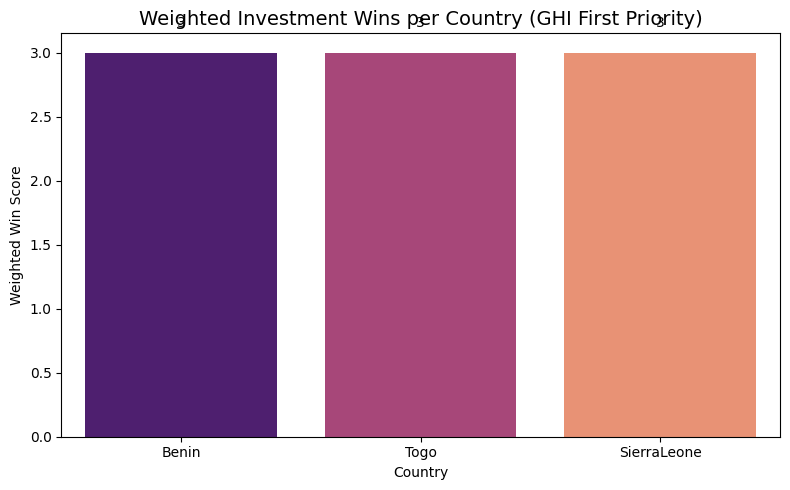

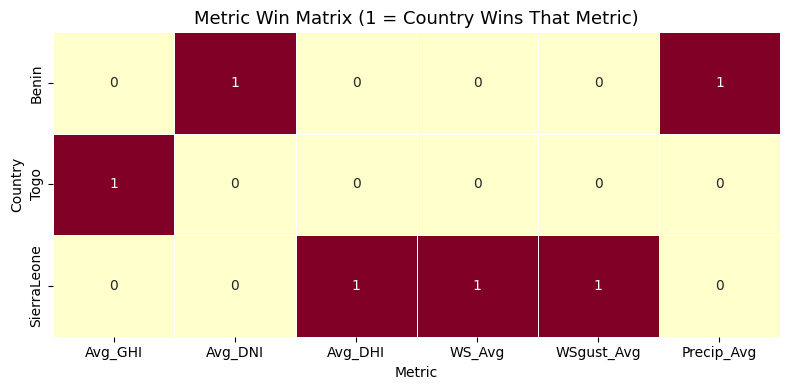


✅ Based on weighted metrics (GHI prioritized), the best country to invest in is: **Benin**

📁 Weighted summary saved to '../final/weighted_metric_summary.csv'


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === Load your final data ===
file_path = Path("../final/final2.csv")
summary_df = pd.read_csv(file_path)

# === Define metrics and their importance ===
# Higher weight = more important for investment
metrics = {
    'Avg_GHI': {'mode': 'max', 'weight': 3},   # Most important
    'Avg_DNI': {'mode': 'max', 'weight': 2},
    'Avg_DHI': {'mode': 'max', 'weight': 1},
    'WS_Avg': {'mode': 'min', 'weight': 1},
    'WSgust_Avg': {'mode': 'min', 'weight': 1},
    'Precip_Avg': {'mode': 'min', 'weight': 1}
}

# === Helper function to find winners ===
def find_winners(df, metrics):
    winners = {}
    for metric, rule in metrics.items():
        if metric not in df.columns:
            continue
        if rule['mode'] == 'max':
            best_val = df[metric].max()
            winners[metric] = df.loc[df[metric] == best_val, 'Country'].tolist()
        elif rule['mode'] == 'min':
            best_val = df[metric].min()
            winners[metric] = df.loc[df[metric] == best_val, 'Country'].tolist()
        elif rule['mode'] == 'closest':
            target = rule.get('target', 30)
            dist = (df[metric] - target).abs()
            best_val = dist.min()
            winners[metric] = df.loc[dist == best_val, 'Country'].tolist()
    return winners

# === Find winners for each metric ===
winners = find_winners(summary_df, metrics)

# === Weighted win counting ===
weighted_wins = {c: 0 for c in summary_df['Country']}
for metric, countries in winners.items():
    for c in countries:
        weighted_wins[c] += metrics[metric]['weight']

# === Create DataFrame for plotting ===
weighted_df = pd.DataFrame({
    'Country': list(weighted_wins.keys()),
    'Weighted_Wins': list(weighted_wins.values())
}).sort_values(by='Weighted_Wins', ascending=False)

# === 1️⃣ Bar Chart: Weighted Wins (Investment Score by Importance) ===
plt.figure(figsize=(8, 5))
sns.barplot(data=weighted_df, x='Country', y='Weighted_Wins', palette='magma')
plt.title("Weighted Investment Wins per Country (GHI First Priority)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Weighted Win Score")
for index, row in weighted_df.iterrows():
    plt.text(index, row['Weighted_Wins'] + 0.2, int(row['Weighted_Wins']), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# === 2️⃣ Heatmap: Which Country Wins Which Metric ===
heat_data = pd.DataFrame(0, index=summary_df['Country'], columns=metrics.keys())
for metric, countries in winners.items():
    for c in countries:
        heat_data.loc[c, metric] = 1

plt.figure(figsize=(8, 4))
sns.heatmap(heat_data, annot=True, cmap='YlOrRd', cbar=False, linewidths=0.5)
plt.title("Metric Win Matrix (1 = Country Wins That Metric)", fontsize=13)
plt.xlabel("Metric")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# === Final Recommendation ===
best_country = weighted_df.loc[weighted_df['Weighted_Wins'].idxmax(), 'Country']
print(f"\n✅ Based on weighted metrics (GHI prioritized), the best country to invest in is: **{best_country}**")

# Save summary for record
weighted_df.to_csv("../final/weighted_metric_summary.csv", index=False)
print("\n📁 Weighted summary saved to '../final/weighted_metric_summary.csv'")
